# Dataset V3 Cooling Scenario Simulation

This notebook uses the final Dataset V3 XGBoost model to simulate cooling interventions across sampled locations.

Two scenarios are evaluated:

1. Urban greening: increase vegetation and reduce built-up intensity.
2. Cool and permeable surfaces: reduce built-up intensity.

Scenario results are model-based estimates. They are intended for comparative planning and prioritization, not as guaranteed real-world temperature reductions.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

df_scenario_v3 = pd.read_csv(
    "../data/processed/hotspot_predictions_v3.csv"
)

final_xgb_v3 = joblib.load(
    "../outputs/models/xgboost_v3_landcover_model.pkl"
)

feature_order_v3 = pd.read_csv(
    "../outputs/models/xgboost_v3_feature_order.csv"
)["Feature"].tolist()

print("Scenario dataset loaded:", df_scenario_v3.shape)
print("Model features:", len(feature_order_v3))

Scenario dataset loaded: (9893, 21)
Model features: 11


In [2]:
X_baseline_v3 = df_scenario_v3[feature_order_v3].copy()

df_scenario_v3["Baseline_Predicted_LST"] = (
    final_xgb_v3.predict(X_baseline_v3)
)

print(
    df_scenario_v3["Baseline_Predicted_LST"]
    .describe()
    .round(2)
)

count    9893.00
mean       43.46
std         2.66
min        27.74
25%        41.64
50%        43.71
75%        45.63
max        49.93
Name: Baseline_Predicted_LST, dtype: float64


In [3]:
# Urban greening scenario:
# NDVI increases by 20%, capped at the valid maximum of 1.
# NDBI decreases by 10% to represent reduced impervious built-up intensity.

X_greening_v3 = X_baseline_v3.copy()

X_greening_v3["NDVI"] = (
    X_greening_v3["NDVI"] * 1.20
).clip(upper=1)

X_greening_v3["NDBI"] = (
    X_greening_v3["NDBI"] * 0.90
)

df_scenario_v3["Greening_Predicted_LST"] = (
    final_xgb_v3.predict(X_greening_v3)
)

df_scenario_v3["Greening_Cooling_C"] = (
    df_scenario_v3["Baseline_Predicted_LST"]
    - df_scenario_v3["Greening_Predicted_LST"]
)

print("Urban greening cooling summary:")
print(
    df_scenario_v3["Greening_Cooling_C"]
    .describe()
    .round(3)
)

Urban greening cooling summary:
count    9893.000
mean        0.257
std         0.663
min        -5.217
25%        -0.145
50%         0.271
75%         0.684
max         4.198
Name: Greening_Cooling_C, dtype: float64


In [4]:
# Cool and permeable surfaces scenario:
# NDBI decreases by 20% to represent reduced built-up heat contribution.

X_cool_surface_v3 = X_baseline_v3.copy()

X_cool_surface_v3["NDBI"] = (
    X_cool_surface_v3["NDBI"] * 0.80
)

df_scenario_v3["Cool_Surface_Predicted_LST"] = (
    final_xgb_v3.predict(X_cool_surface_v3)
)

df_scenario_v3["Cool_Surface_Cooling_C"] = (
    df_scenario_v3["Baseline_Predicted_LST"]
    - df_scenario_v3["Cool_Surface_Predicted_LST"]
)

print("Cool/permeable surface cooling summary:")
print(
    df_scenario_v3["Cool_Surface_Cooling_C"]
    .describe()
    .round(3)
)

Cool/permeable surface cooling summary:
count    9893.000
mean        0.076
std         0.440
min        -3.006
25%        -0.156
50%         0.073
75%         0.350
max         2.229
Name: Cool_Surface_Cooling_C, dtype: float64


In [5]:
df_scenario_v3["Best_Cooling_C"] = df_scenario_v3[
    [
        "Greening_Cooling_C",
        "Cool_Surface_Cooling_C"
    ]
].max(axis=1)

df_scenario_v3["Recommended_Intervention"] = np.where(
    df_scenario_v3["Greening_Cooling_C"]
    >= df_scenario_v3["Cool_Surface_Cooling_C"],
    "Urban greening",
    "Cool/permeable surfaces"
)

print("Recommended intervention counts:")
print(
    df_scenario_v3["Recommended_Intervention"]
    .value_counts()
)

print("\nBest cooling summary:")
print(
    df_scenario_v3["Best_Cooling_C"]
    .describe()
    .round(3)
)

Recommended intervention counts:
Recommended_Intervention
Urban greening             6272
Cool/permeable surfaces    3621
Name: count, dtype: int64

Best cooling summary:
count    9893.000
mean        0.394
std         0.544
min        -2.770
25%         0.032
50%         0.372
75%         0.720
max         4.198
Name: Best_Cooling_C, dtype: float64


In [6]:
# Reuse Zone_ID created in hotspot detection.
# If it is missing, create it again.

if "Zone_ID" not in df_scenario_v3.columns:
    grid_size = 0.02

    lat_block = np.floor(
        (df_scenario_v3["Latitude"] - df_scenario_v3["Latitude"].min())
        / grid_size
    ).astype(int)

    lon_block = np.floor(
        (df_scenario_v3["Longitude"] - df_scenario_v3["Longitude"].min())
        / grid_size
    ).astype(int)

    df_scenario_v3["Zone_ID"] = (
        lat_block.astype(str)
        + "_"
        + lon_block.astype(str)
    )

zone_intervention_v3 = (
    df_scenario_v3.groupby("Zone_ID")
    .agg(
        Mean_Baseline_LST=("Baseline_Predicted_LST", "mean"),
        Mean_Greening_Cooling_C=("Greening_Cooling_C", "mean"),
        Mean_Cool_Surface_Cooling_C=("Cool_Surface_Cooling_C", "mean"),
        Mean_Best_Cooling_C=("Best_Cooling_C", "mean"),
        Mean_Population=("Population", "mean"),
        Zone_Latitude=("Latitude", "mean"),
        Zone_Longitude=("Longitude", "mean"),
        Point_Count=("LST", "count")
    )
    .reset_index()
)

zone_intervention_v3["Recommended_Intervention"] = np.where(
    zone_intervention_v3["Mean_Greening_Cooling_C"]
    >= zone_intervention_v3["Mean_Cool_Surface_Cooling_C"],
    "Urban greening",
    "Cool/permeable surfaces"
)

zone_intervention_v3 = zone_intervention_v3.sort_values(
    by="Mean_Best_Cooling_C",
    ascending=False
).reset_index(drop=True)

print("Top 10 zones by cooling potential:")
display(zone_intervention_v3.head(10))

Top 10 zones by cooling potential:


,Zone_ID,Mean_Baseline_LST,Mean_Greening_Cooling_C,Mean_Cool_Surface_Cooling_C,Mean_Best_Cooling_C,Mean_Population,Zone_Latitude,Zone_Longitude,Point_Count,Recommended_Intervention
0,0_6,43.506454,1.097858,0.472767,1.169778,2.641625,19.733412,75.272997,30,Urban greening
1,13_9,44.616367,0.900969,0.319292,1.034609,1.135171,19.993966,75.332386,30,Urban greening
2,6_20,45.721588,0.910720,0.299620,0.922871,5.377040,19.853783,75.551956,32,Urban greening
3,9_7,44.981224,0.858206,0.319060,0.885526,14.635487,19.914050,75.290979,27,Urban greening
4,4_21,46.940758,0.742268,0.324992,0.796997,2.618992,19.813187,75.571824,29,Urban greening
5,4_20,46.277409,0.686613,0.386653,0.791900,2.684914,19.812505,75.552733,36,Urban greening
6,2_11,45.697147,0.737511,0.482929,0.791033,1.515464,19.772852,75.371829,34,Urban greening
7,5_0,42.711670,0.370827,0.785172,0.785172,1.565967,19.841369,75.161099,1,Cool/permeable surfaces
8,10_22,46.160492,0.777173,0.177707,0.777173,2.422858,19.937127,75.583262,4,Urban greening
9,13_7,44.584919,0.565610,0.350590,0.774927,1.111110,19.992573,75.290690,32,Urban greening


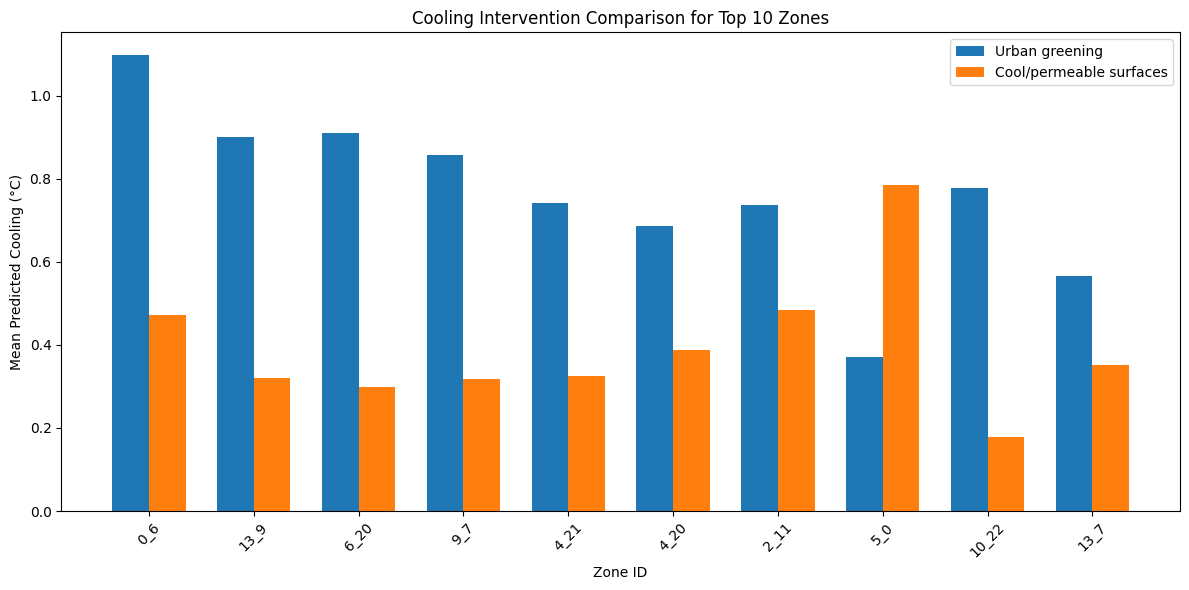

In [7]:
top_intervention_zones = zone_intervention_v3.head(10)

x = np.arange(len(top_intervention_zones))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    top_intervention_zones["Mean_Greening_Cooling_C"],
    width,
    label="Urban greening"
)

plt.bar(
    x + width / 2,
    top_intervention_zones["Mean_Cool_Surface_Cooling_C"],
    width,
    label="Cool/permeable surfaces"
)

plt.xticks(
    x,
    top_intervention_zones["Zone_ID"],
    rotation=45
)

plt.xlabel("Zone ID")
plt.ylabel("Mean Predicted Cooling (°C)")
plt.title("Cooling Intervention Comparison for Top 10 Zones")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
scenario_summary_v3 = pd.DataFrame({
    "Scenario": [
        "Urban greening",
        "Cool/permeable surfaces"
    ],
    "Mean_Cooling_C": [
        df_scenario_v3["Greening_Cooling_C"].mean(),
        df_scenario_v3["Cool_Surface_Cooling_C"].mean()
    ],
    "Maximum_Cooling_C": [
        df_scenario_v3["Greening_Cooling_C"].max(),
        df_scenario_v3["Cool_Surface_Cooling_C"].max()
    ]
}).round(3)

scenario_summary_v3

,Scenario,Mean_Cooling_C,Maximum_Cooling_C
0,Urban greening,0.257,4.198
1,Cool/permeable surfaces,0.076,2.229


In [9]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

df_scenario_v3.to_csv(
    "../data/processed/scenario_predictions_v3.csv",
    index=False
)

zone_intervention_v3.to_csv(
    "../outputs/reports/intervention_priority_v3.csv",
    index=False
)

scenario_summary_v3.to_csv(
    "../outputs/reports/scenario_summary_v3.csv",
    index=False
)

print("Saved:")
print("data/processed/scenario_predictions_v3.csv")
print("outputs/reports/intervention_priority_v3.csv")
print("outputs/reports/scenario_summary_v3.csv")

Saved:
data/processed/scenario_predictions_v3.csv
outputs/reports/intervention_priority_v3.csv
outputs/reports/scenario_summary_v3.csv


## Dataset V3 Scenario Simulation Conclusion

Two model-based cooling scenarios were evaluated using the final Dataset V3 XGBoost model: urban greening and cool/permeable surfaces.

Urban greening was represented by a 20% increase in NDVI and a 10% reduction in NDBI. Cool/permeable surfaces were represented by a 20% reduction in NDBI.

For each sampled location and spatial zone, the intervention with the greater predicted cooling was selected as the recommended strategy. Zones were ranked by mean predicted cooling potential.

These results are comparative model-based planning estimates and should be interpreted alongside local feasibility, land availability, implementation cost, and on-ground validation.